# 📩 SMS Spam Detection using Naive Bayes & TF-IDF

Welcome to the **Spam Detector** notebook. In this project, we build a complete Machine Learning pipeline to classify text messages (SMS) as either **Ham** (legitimate) or **Spam** (unwanted).

### Project Workflow:
1. **Data Loading & Inspection**: Load the raw dataset and inspect its structure.
2. **Data Cleaning**: Filter relevant columns and handle missing values.
3. **Exploratory Data Analysis (EDA)**: Analyze and visualize class distributions.
4. **Text Preprocessing**: Lowercase text, remove punctuation, remove digits, and strip extra spaces.
5. **Feature Extraction**: Convert preprocessed text into numerical feature vectors using **TF-IDF Vectorization**.
6. **Train-Test Split**: Divide data into training (80%) and testing (20%) sets with stratified sampling.
7. **Model Training**: Train a **Multinomial Naive Bayes** classifier.
8. **Model Evaluation**: Measure performance via Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
9. **Inference & Model Persistence**: Save model artifacts and run predictions on sample text messages.


In [1]:
# Step 1: Import Required Libraries
import re
import string
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


## 1. Data Loading & Initial Inspection
We begin by reading the CSV dataset (`data/spam.csv`) using Pandas and examining its columns.

In [2]:
# Load the dataset
data_path = "data/spam.csv"
data = pd.read_csv(data_path, encoding='latin-1')

# Display dataset columns and first few records
print("Raw Columns:", data.columns.tolist())
data.head()


Raw Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


## 2. Data Cleaning & Column Renaming
We extract only the target label column (`v1`) and text message column (`v2`), renaming them to `label` and `message` for clarity.

In [3]:
# Retain only relevant columns and rename them
df = data[['v1', 'v2']].copy()
df.columns = ['label', 'message']

# Display cleaned DataFrame head
df.head()


## 3. Exploratory Data Analysis (EDA)
Let's inspect the target label distribution to check for class imbalance.

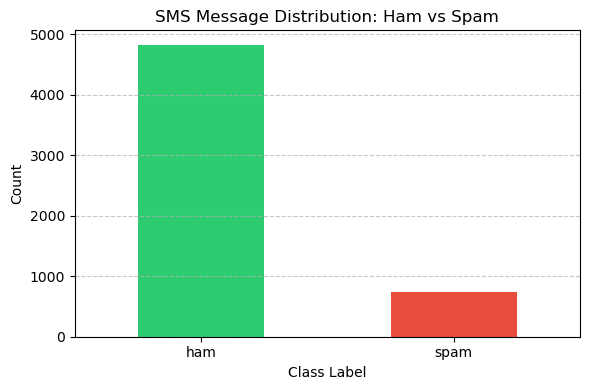

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
# Class counts
print("Class Distribution:")
print(df['label'].value_counts())

# Visualizing class distribution
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('SMS Message Distribution: Ham vs Spam')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 4. Text Preprocessing
Text normalization includes:
- **Lowercasing**: Convert all characters to lowercase.
- **Digit Removal**: Remove all numeric digits.
- **Punctuation Removal**: Remove special characters and punctuation marks.
- **Whitespace Stripping**: Eliminate duplicate and trailing spaces.


In [5]:
def clean_text(text):
    """
    Cleans input text by lowercasing, removing numbers,
    removing punctuation, and stripping extra whitespace.
    """
    text = str(text).lower()
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply text cleaning
df['clean_message'] = df['message'].fillna('').apply(clean_text)

# Inspect original vs cleaned messages
df[['message', 'clean_message']].head()


## 5. Feature Extraction (TF-IDF Vectorization)
We transform text strings into numerical feature matrices using **Term Frequency-Inverse Document Frequency (TF-IDF)** with English stop-words removal.

In [6]:
# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# Fit and transform preprocessed messages
X = vectorizer.fit_transform(df['clean_message'])
y = df['label']

print("TF-IDF Feature Matrix Shape:", X.shape)


TF-IDF Feature Matrix Shape: (5572, 5000)


## 6. Train-Test Split
We partition the dataset into 80% training data and 20% test data using stratified sampling to maintain label ratios.

In [7]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set samples: {X_train.shape[0]}")
print(f"Test set samples:     {X_test.shape[0]}")


Training set samples: 4457
Test set samples:     1115


## 7. Model Training (Multinomial Naive Bayes)
We fit a **Multinomial Naive Bayes** classifier on the training feature matrix.

In [8]:
# Instantiate and train model
model = MultinomialNB()
model.fit(X_train, y_train)

print("Multinomial Naive Bayes trained successfully.")


Multinomial Naive Bayes trained successfully.


## 8. Model Evaluation
We evaluate predictions against ground-truth test labels using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

In [9]:
# Generate predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label='spam', zero_division=0)
rec = recall_score(y_test, y_pred, pos_label='spam', zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label='spam', zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])
print("Confusion Matrix:")
print(cm)


Accuracy:  0.9677
Precision: 0.9913
Recall:    0.7651
F1 Score:  0.8636

Classification Report:
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115

Confusion Matrix:
[[965   1]
 [ 35 114]]


## 9. Model Persistence & Inference
We save the vectorizer and trained model using `pickle` and test inference on unseen sample messages.

In [10]:
# Save model artifacts using pickle
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Saved vectorizer and model to disk.")

# Load artifacts for verification
with open('vectorizer.pkl', 'rb') as f:
    loaded_vectorizer = pickle.load(f)

with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Inference test
sample_messages = [
    "Congratulations! You've won a $1,000 gift card! Claim now at http://example.com",
    "Hey, are we still meeting for lunch at 1 PM today?"
]

cleaned_samples = [clean_text(msg) for msg in sample_messages]
sample_features = loaded_vectorizer.transform(cleaned_samples)
predictions = loaded_model.predict(sample_features)

for text, pred in zip(sample_messages, predictions):
    print("Message:    ", text)
    print("Prediction: ", pred.upper())
    print()


Saved vectorizer and model to disk.
Message:     Congratulations! You've won a $1,000 gift card! Claim now at http://example.com
Prediction:  SPAM

Message:     Hey, are we still meeting for lunch at 1 PM today?
Prediction:  HAM

